# Clustering Baseline

Clustering analysis of BIM OBB features using:
- **MiniBatchKMeans**: Fast, scalable k-means
- **BisectingKMeans**: Hierarchical k-means, no empty clusters
- **HDBSCAN**: Density-based, auto k, noise-robust

**Features:**
- Length (L): Maximum OBB extent
- Cross Section Area (C): W × H
- Volume (V): L × W × H
- Number of Vertices (N): Mesh complexity

**Hyperparameter selection:** Grid search using silhouette score

In [55]:
!pip install umap-learn

  Using cached umap_learn-0.5.9.post2-py3-none-any.whl.metadata (25 kB)
  Using cached pynndescent-0.5.13-py3-none-any.whl.metadata (6.8 kB)
Using cached umap_learn-0.5.9.post2-py3-none-any.whl (90 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 2.7 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 9.8 MB/s  0:00:03 eta 0:00:01m
Using cached pynndescent-0.5.13-py3-none-any.whl (56 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [umap-learn]4 [numba]


In [1]:
%load_ext autoreload

In [2]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from clustering import (
    load_features, get_feature_matrix,
    grid_search_kmeans, grid_search_bisecting_kmeans, grid_search_hdbscan,
    evaluate, compare_results,
    plot_silhouette_curve, plot_grid_search_heatmap,
    plot_algorithm_comparison, plot_silhouette_analysis,
    plot_2d_projection, plot_cluster_sizes,
    # IFC type analysis
    analyze_cluster_composition, plot_cluster_ifc_heatmap,
    plot_type_cluster_distribution, print_cluster_summary,
)

# Data paths
FEATURES_PATH = '../../processed_data/features/train_features.parquet'

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
# Load data
df = load_features(FEATURES_PATH)
print(f"Loaded {len(df):,} samples")
print(f"IFC Types: {df['IfcType'].nunique()}")
df.head()

Loaded 128,883 samples
IFC Types: 24


,Length,CrossSectionArea,Volume,NumVertices,GlobalId,IfcType,Split
0,1.222222,0.008400,0.010267,16,0$0GYP0JdAGwJQwKesJ2vU,IfcBuildingElementProxy,train
1,0.450000,0.006720,0.003024,20,0$0nVxXg$6IwQL3YuZDtXR,IfcBuildingElementProxy,train
2,16.000000,0.586500,9.384000,8,0$25K5WGf2PONJd_QXyFMd,IfcBuildingElementPart,train
3,32.770000,2.336850,76.578574,28,0$3o8Y31tFHfJISlNmJbhS,IfcRoof,train
4,4.670228,8.197632,38.284807,1380,0$4HcVk7n7g8rb8Jqw82FW,IfcStair,train


## 1. Preprocessing

Extract features and apply RobustScaler (handles outliers via median/IQR).

In [4]:
X, feature_names, scaler = get_feature_matrix(df)
print(f"Feature matrix shape: {X.shape}")
print(f"Features: {feature_names}")

Feature matrix shape: (128883, 4)
Features: ['Length', 'CrossSectionArea', 'Volume', 'NumVertices']


## 2. Grid Search: KMeans

Find optimal k using silhouette score.

In [5]:
kmeans_search = grid_search_kmeans(X, n_clusters_range=[5,6,7,8,9,10,15,20,24])

print(f"\nBest KMeans: k={kmeans_search.best_result.params['n_clusters']}, "
      f"silhouette={kmeans_search.best_result.silhouette:.3f}")

KMeans:   0%|          | 0/9 [00:00<?, ?it/s]


Best KMeans: k=5, silhouette=0.490


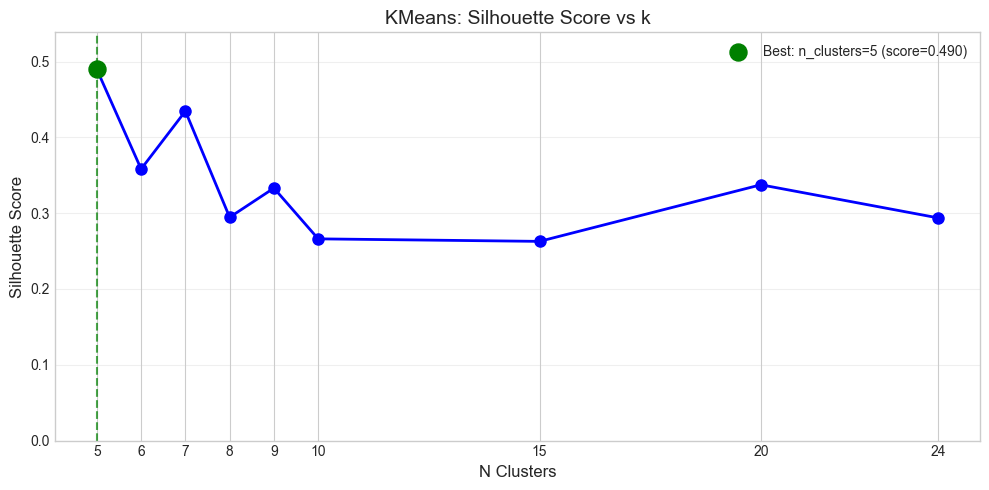

In [6]:
plot_silhouette_curve(kmeans_search.all_results, param_key='n_clusters', 
                      title='KMeans: Silhouette Score vs k')
plt.show()

## 3. Grid Search: BisectingKMeans

Hierarchical divisive clustering - splits clusters recursively.

In [7]:
bisecting_search = grid_search_bisecting_kmeans(X, n_clusters_range=[5,6,7,8,9,10, 15, 20, 24])

print(f"\nBest BisectingKMeans: k={bisecting_search.best_result.params['n_clusters']}, "
      f"silhouette={bisecting_search.best_result.silhouette:.3f}")

BisectingKMeans:   0%|          | 0/9 [00:00<?, ?it/s]


Best BisectingKMeans: k=5, silhouette=0.961


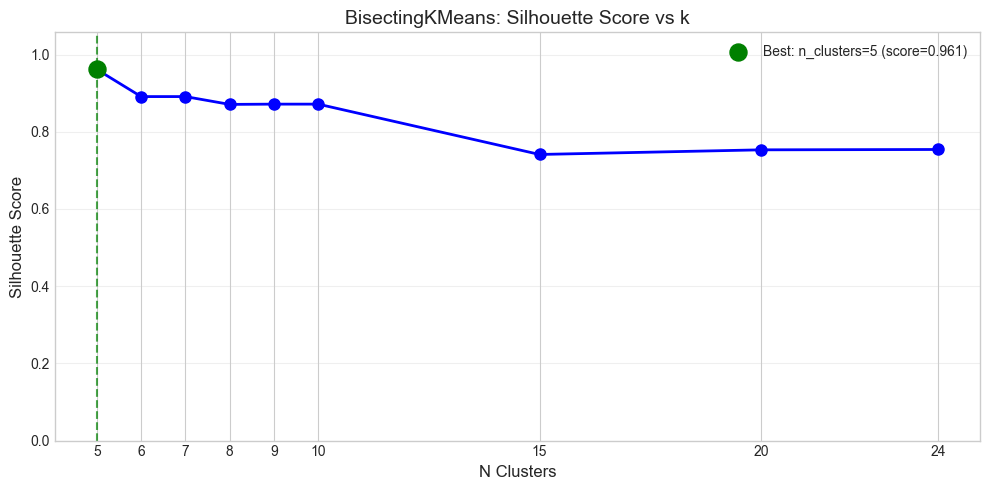

In [8]:
plot_silhouette_curve(bisecting_search.all_results, param_key='n_clusters',
                      title='BisectingKMeans: Silhouette Score vs k')
plt.show()

## 4. Grid Search: HDBSCAN

Density-based clustering with automatic cluster detection.

In [9]:
hdbscan_search = grid_search_hdbscan(
    X,
    min_cluster_size_range=[100, 200, 500,1000],
    min_samples_range=[5, 10, 25, 50]
)

best_hdb = hdbscan_search.best_result
print(f"\nBest HDBSCAN: min_cluster_size={best_hdb.params['min_cluster_size']}, "
      f"min_samples={best_hdb.params['min_samples']}, "
      f"silhouette={best_hdb.silhouette:.3f}")

HDBSCAN:   0%|          | 0/16 [00:00<?, ?it/s]


Best HDBSCAN: min_cluster_size=1000, min_samples=25, silhouette=0.639


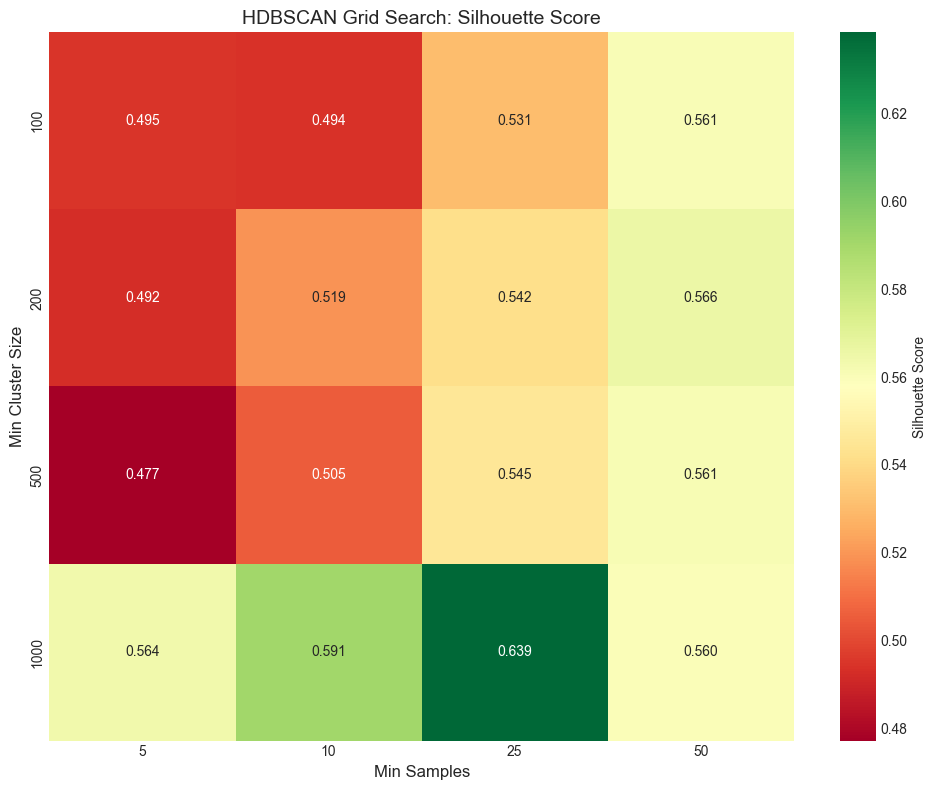

In [10]:
plot_grid_search_heatmap(hdbscan_search.all_results)
plt.show()

In [11]:
# Show all HDBSCAN results
hdbscan_df = pd.DataFrame(hdbscan_search.all_results)
hdbscan_df['params'] = hdbscan_df['params'].apply(lambda x: f"mcs={x['min_cluster_size']}, ms={x['min_samples']}")
print(hdbscan_df.sort_values('silhouette', ascending=False).to_string(index=False))

         params  silhouette  n_clusters  noise_ratio
mcs=1000, ms=25    0.638597          29     0.583064
mcs=1000, ms=10    0.591044          31     0.584406
 mcs=200, ms=50    0.565983         170     0.444682
 mcs=1000, ms=5    0.563837          32     0.564683
 mcs=500, ms=50    0.561266          70     0.480048
 mcs=100, ms=50    0.560570         389     0.398284
mcs=1000, ms=50    0.559983          33     0.532118
 mcs=500, ms=25    0.545287          69     0.468099
 mcs=200, ms=25    0.541815         186     0.403265
 mcs=100, ms=25    0.530530         429     0.352863
 mcs=200, ms=10    0.519399         190     0.395002
 mcs=500, ms=10    0.505291          65     0.477611
  mcs=100, ms=5    0.494545         453     0.314549
 mcs=100, ms=10    0.493821         453     0.321741
  mcs=200, ms=5    0.492416         195     0.378995
  mcs=500, ms=5    0.477151          69     0.455522


## 5. Algorithm Comparison

Compare best results from each algorithm.

In [12]:
# Collect best results
results = {
    'KMeans': {'result': kmeans_search.best_result, 'metrics': evaluate(X, kmeans_search.best_result.labels)},
    'BisectingKMeans': {'result': bisecting_search.best_result, 'metrics': evaluate(X, bisecting_search.best_result.labels)},
    'HDBSCAN': {'result': hdbscan_search.best_result, 'metrics': evaluate(X, hdbscan_search.best_result.labels)},
}

# Summary
print("Best hyperparameters:")
for name, res in results.items():
    print(f"  {name}: {res['result'].params}")

Best hyperparameters:
  KMeans: {'n_clusters': 5}
  BisectingKMeans: {'n_clusters': 5}
  HDBSCAN: {'min_cluster_size': 1000, 'min_samples': 25}


In [13]:
# Create comparison table
comparison_df = compare_results(results)
print("\nMetrics Comparison:")
display(comparison_df)


Metrics Comparison:


,silhouette,calinski_harabasz,davies_bouldin,n_clusters,noise_ratio
algorithm,,,,,
KMeans,0.488723,16269.064420,1.084592,5,0.000000
BisectingKMeans,0.961519,118075.843074,0.490315,5,0.000000
HDBSCAN,0.634320,149594.838748,0.483573,29,0.583064


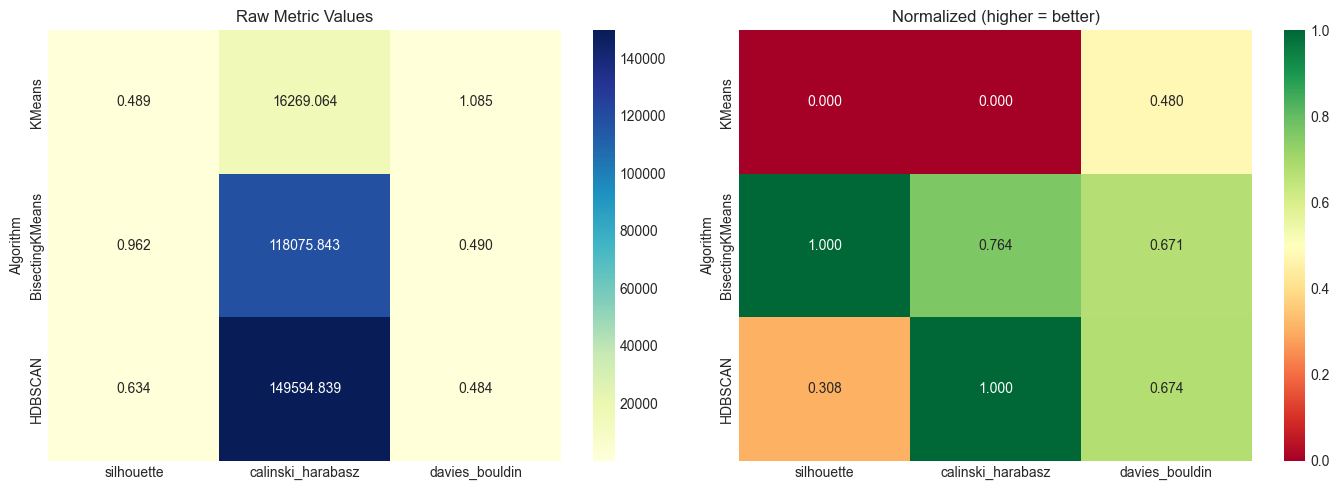

In [14]:
plot_algorithm_comparison(comparison_df)
plt.show()

## 7. Cluster Sizes

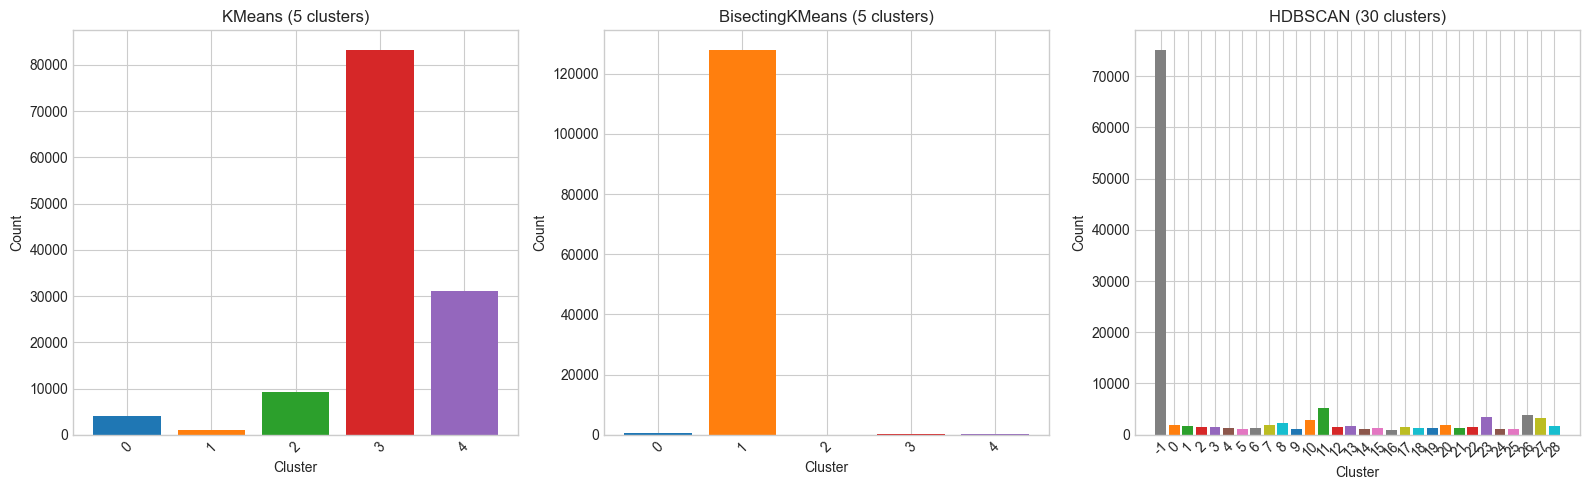

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, res) in zip(axes, results.items()):
    labels = res['result'].labels
    unique, counts = np.unique(labels, return_counts=True)
    colors = ['gray' if l == -1 else f'C{i % 10}' for i, l in enumerate(unique)]
    ax.bar([str(l) for l in unique], counts, color=colors)
    ax.set_title(f'{name} ({len(unique)} clusters)')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 8. 2D Projection

Visualize clusters using PCA.

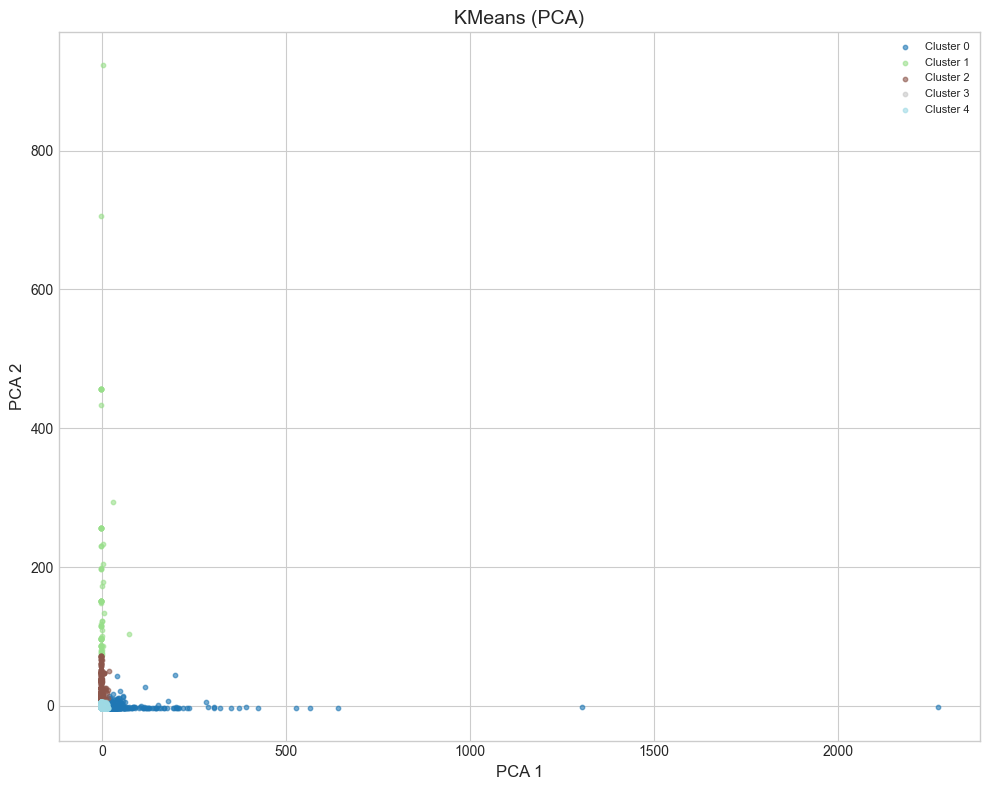

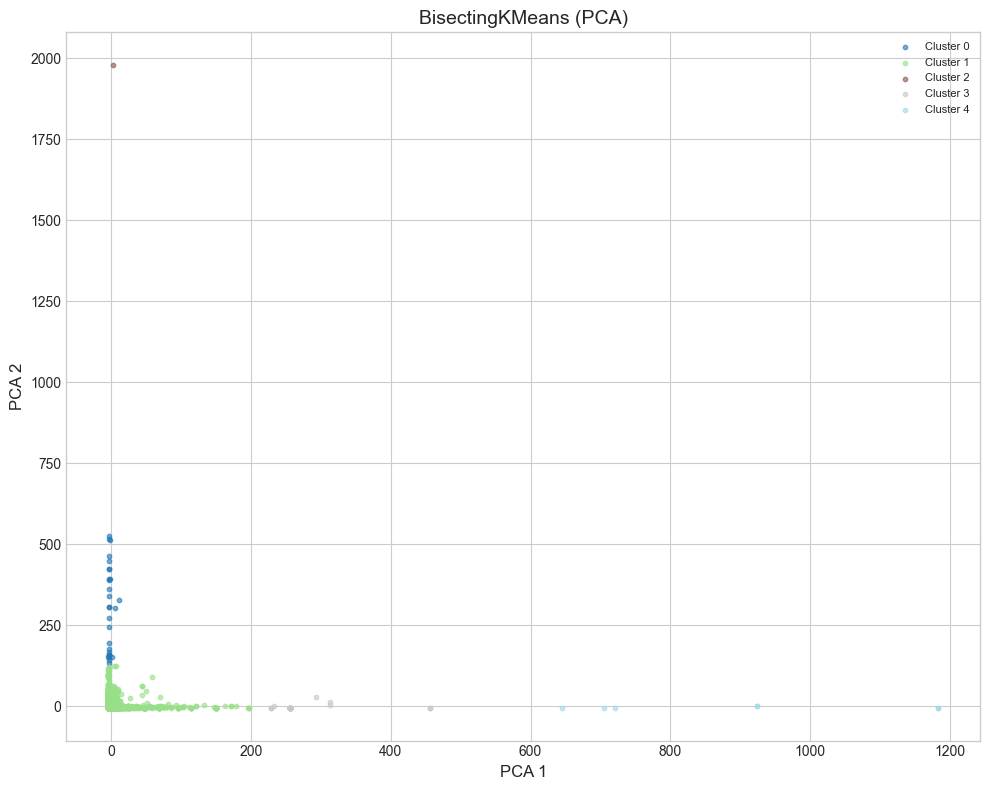

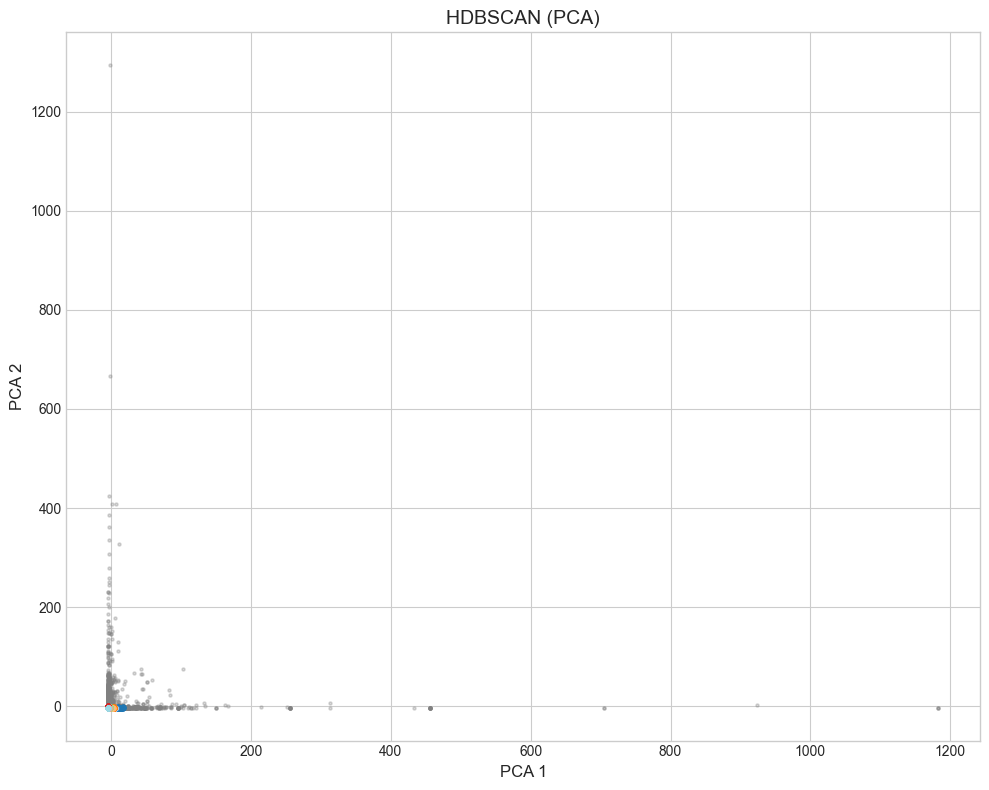

In [16]:
for name, res in results.items():
    plot_2d_projection(X, res['result'].labels, method='pca', title=f'{name} (PCA)')
    plt.show()

/opt/miniconda3/envs/bentley/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


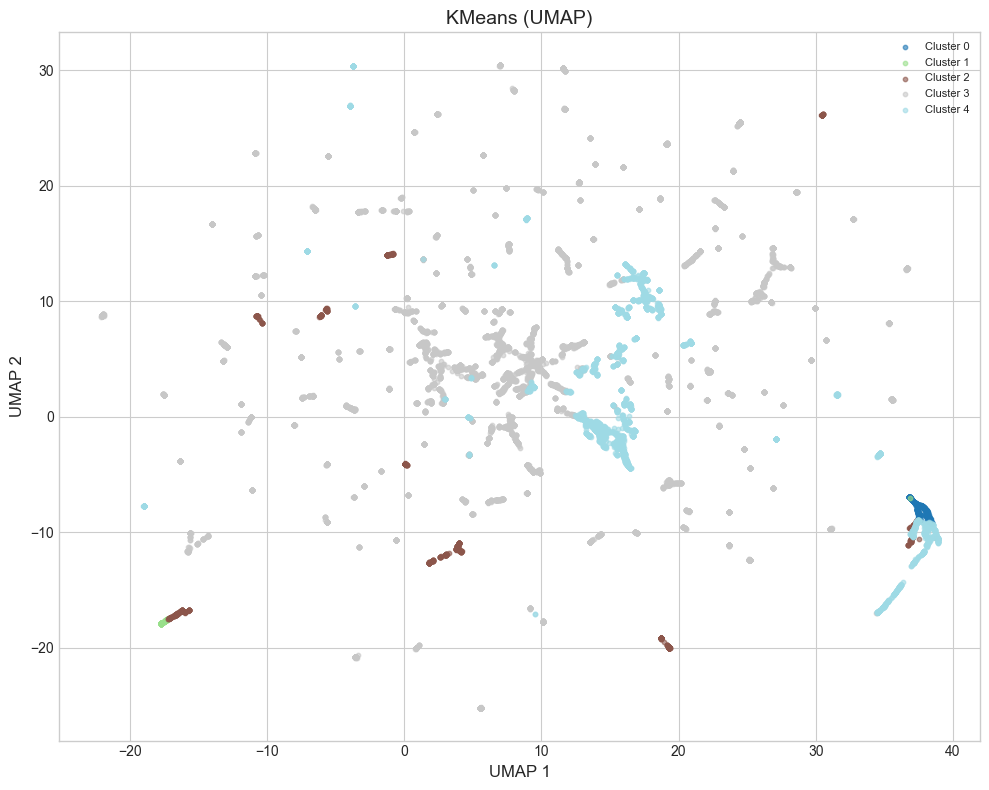

In [17]:
# UMAP projection (if available)
plot_2d_projection(X, kmeans_search.best_result.labels, method='umap', title='KMeans (UMAP)')
plt.show()

## Summary

In [20]:
print("=" * 60)
print("CLUSTERING SUMMARY")
print("=" * 60)

for name, res in results.items():
    metrics = res['metrics']
    params = res['result'].params
    if metrics:
        print(f"\n{name}:")
        print(f"  Params: {params}")
        print(f"  Clusters: {metrics['n_clusters']}")
        print(f"  Silhouette: {metrics['silhouette']:.3f}")
        print(f"  Calinski-Harabasz: {metrics['calinski_harabasz']:.1f}")
        print(f"  Davies-Bouldin: {metrics['davies_bouldin']:.3f}")
        print(f"  Noise ratio: {metrics['noise_ratio']:.1%}")

CLUSTERING SUMMARY

KMeans:
  Params: {'n_clusters': 5}
  Clusters: 5
  Silhouette: 0.489
  Calinski-Harabasz: 16269.1
  Davies-Bouldin: 1.085
  Noise ratio: 0.0%

BisectingKMeans:
  Params: {'n_clusters': 5}
  Clusters: 5
  Silhouette: 0.962
  Calinski-Harabasz: 118075.8
  Davies-Bouldin: 0.490
  Noise ratio: 0.0%

HDBSCAN:
  Params: {'min_cluster_size': 1000, 'min_samples': 25}
  Clusters: 29
  Silhouette: 0.634
  Calinski-Harabasz: 149594.8
  Davies-Bouldin: 0.484
  Noise ratio: 58.3%


## 9. IFC Type Analysis (Qualitative Evaluation)

Internal metrics (silhouette, etc.) are blind to domain semantics. We need to check if clusters align with IFC types.

**Key Questions:**
- Do clusters correspond to structural/semantic categories?
- Is the BisectingKMeans 0.962 silhouette suspicious? (Check cluster sizes)
- What's the **purity** score? (Higher = clusters match IFC types)

In [21]:
# Check BisectingKMeans cluster sizes - is 0.962 silhouette suspicious?
print("BisectingKMeans Cluster Sizes:")
print("-" * 40)
bisect_labels = results['BisectingKMeans']['result'].labels
from collections import Counter
sizes = Counter(bisect_labels)
for cluster, count in sorted(sizes.items(), key=lambda x: -x[1]):
    pct = count / len(bisect_labels) * 100
    print(f"  Cluster {cluster}: {count:,} ({pct:.1f}%)")

BisectingKMeans Cluster Sizes:
----------------------------------------
  Cluster 1: 128,002 (99.3%)
  Cluster 0: 437 (0.3%)
  Cluster 3: 317 (0.2%)
  Cluster 4: 99 (0.1%)
  Cluster 2: 28 (0.0%)


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from typing import Dict, List, Optional
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples

def print_cluster_summary(
    labels: np.ndarray,
    ifc_types: np.ndarray | pd.Series,
    top_n: int = 10
) -> None:
    """Print summary of dominant IFC types per cluster.

    Parameters
    ----------
    labels : np.ndarray
        Cluster labels
    ifc_types : array-like
        IFC type for each sample
    top_n : int
        Show top N clusters
    """
    analysis = analyze_cluster_composition(labels, ifc_types)

    print(f"Purity Score: {analysis['purity']:.3f}")
    print(f"\nTop {top_n} Clusters by Dominant Type:")
    print("-" * 60)

    # Get cluster sizes
    cluster_sizes = pd.Series(labels).value_counts()

    # Sort by size (excluding noise)
    sorted_clusters = cluster_sizes.drop(-1, errors='ignore').head(top_n).index

    for cluster in sorted_clusters:
        dominant = analysis['dominant_types'][cluster]
        strength = analysis['dominance_strength'][cluster]
        size = cluster_sizes[cluster]
        print(f"Cluster {cluster:3d}: {dominant:30s} ({strength:.1%}) - {size:,} samples")

def analyze_cluster_composition(
    labels: np.ndarray,
    ifc_types: np.ndarray | pd.Series
) -> Dict:
    """Analyze cluster composition by IFC type.

    Parameters
    ----------
    labels : np.ndarray
        Cluster labels
    ifc_types : array-like
        IFC type for each sample

    Returns
    -------
    dict
        Dictionary containing:
        - contingency: Absolute counts (clusters x types)
        - cluster_composition: Row-normalized (what types in each cluster)
        - type_distribution: Column-normalized (how each type is distributed)
        - dominant_types: Dominant IFC type per cluster
        - dominance_strength: Proportion of dominant type
        - purity: Weighted purity score
    """
    ifc_types = np.asarray(ifc_types)

    # Create contingency table
    contingency = pd.crosstab(labels, ifc_types, margins=True)

    # Row-normalized: What IFC types are in each cluster?
    cluster_composition = pd.crosstab(labels, ifc_types, normalize='index')

    # Column-normalized: How is each IFC type distributed across clusters?
    type_distribution = pd.crosstab(labels, ifc_types, normalize='columns')

    # Dominant type per cluster
    dominant_types = cluster_composition.idxmax(axis=1)
    dominance_strength = cluster_composition.max(axis=1)

    # Purity score (weighted by cluster size)
    cluster_sizes = pd.Series(labels).value_counts()
    total = cluster_sizes.sum()
    purity = (dominance_strength * cluster_sizes / total).sum()

    return {
        'contingency': contingency,
        'cluster_composition': cluster_composition,
        'type_distribution': type_distribution,
        'dominant_types': dominant_types,
        'dominance_strength': dominance_strength,
        'purity': purity,
    }

In [23]:
# Cluster summary: dominant IFC type per cluster
for name, res in results.items():
    print(f"\n{'='*60}")
    print(f"{name}")
    print('='*60)
    print_cluster_summary(res['result'].labels, df['IfcType'].values, top_n=10)


KMeans
Purity Score: 0.289

Top 10 Clusters by Dominant Type:
------------------------------------------------------------
Cluster   3: IfcMember                      (27.9%) - 83,313 samples
Cluster   4: IfcFurniture                   (21.8%) - 31,191 samples
Cluster   2: IfcFurniture                   (53.1%) - 9,185 samples
Cluster   0: IfcWall                        (43.3%) - 4,099 samples
Cluster   1: IfcFurniture                   (58.4%) - 1,095 samples

BisectingKMeans
Purity Score: 0.187

Top 10 Clusters by Dominant Type:
------------------------------------------------------------
Cluster   1: IfcMember                      (18.4%) - 128,002 samples
Cluster   0: IfcSlab                        (74.8%) - 437 samples
Cluster   3: IfcBuildingElementProxy        (50.5%) - 317 samples
Cluster   4: IfcFurniture                   (59.6%) - 99 samples
Cluster   2: IfcBuildingElementPart         (57.1%) - 28 samples

HDBSCAN
Purity Score: 0.386

Top 10 Clusters by Dominant Type:
-----

### Cluster-IFC Heatmaps

Row-normalized: "What IFC types make up each cluster?"

In [24]:
def plot_cluster_ifc_heatmap(
    labels: np.ndarray,
    ifc_types: np.ndarray | pd.Series,
    top_n_clusters: int = 15,
    top_n_types: int = 15,
    normalize: str = 'index'
) -> plt.Figure:
    """Heatmap showing cluster composition by IFC type.

    Parameters
    ----------
    labels : np.ndarray
        Cluster labels
    ifc_types : array-like
        IFC type for each sample
    top_n_clusters : int
        Show only top N clusters by size (excludes noise)
    top_n_types : int
        Show only top N IFC types by frequency
    normalize : str
        'index' (row) = what types in each cluster
        'columns' = how each type is distributed
        None = absolute counts

    Returns
    -------
    plt.Figure
        Matplotlib figure
    """
    ifc_types = np.asarray(ifc_types)

    # Get top clusters (by size, excluding noise)
    cluster_counts = pd.Series(labels).value_counts()
    if -1 in cluster_counts.index:
        cluster_counts = cluster_counts.drop(-1)
    top_clusters = cluster_counts.head(top_n_clusters).index.tolist()

    # Get top IFC types
    type_counts = pd.Series(ifc_types).value_counts()
    top_types = type_counts.head(top_n_types).index.tolist()

    # Filter data
    mask = np.isin(labels, top_clusters) & np.isin(ifc_types, top_types)
    filtered_labels = labels[mask]
    filtered_types = ifc_types[mask]

    # Create crosstab
    if normalize:
        ct = pd.crosstab(filtered_labels, filtered_types, normalize=normalize)
        fmt = '.2f'
        cbar_label = 'Proportion'
    else:
        ct = pd.crosstab(filtered_labels, filtered_types)
        fmt = 'd'
        cbar_label = 'Count'

    # Sort clusters by size
    cluster_order = [c for c in top_clusters if c in ct.index]
    ct = ct.reindex(cluster_order)

    fig, ax = plt.subplots(figsize=(14, 10))
    sns.heatmap(
        ct, annot=True, fmt=fmt, cmap='YlOrRd', ax=ax,
        cbar_kws={'label': cbar_label}
    )

    title = 'Cluster Composition by IFC Type'
    if normalize == 'index':
        title += ' (row-normalized)'
    elif normalize == 'columns':
        title += ' (column-normalized)'

    ax.set_title(title, fontsize=14)
    ax.set_xlabel('IFC Type', fontsize=12)
    ax.set_ylabel('Cluster', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    return fig

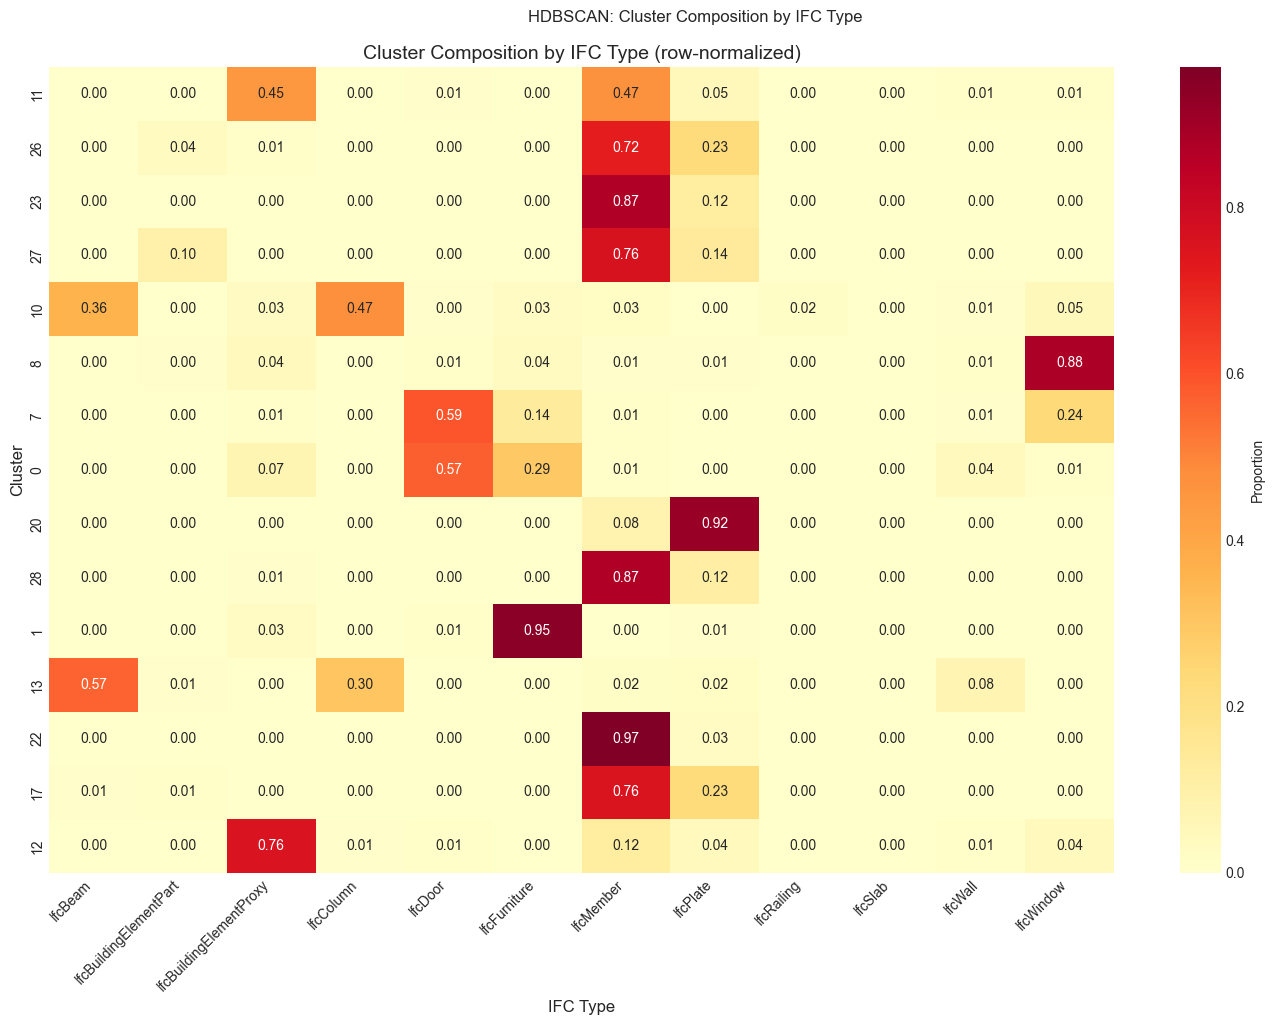

In [25]:
# HDBSCAN cluster composition heatmap (most interesting due to auto-k)
plot_cluster_ifc_heatmap(
    results['HDBSCAN']['result'].labels,
    df['IfcType'].values,
    top_n_clusters=15,
    top_n_types=12,
    normalize='index'
)
plt.suptitle('HDBSCAN: Cluster Composition by IFC Type', y=1.02)
plt.show()

In [26]:
def plot_type_cluster_distribution(
    labels: np.ndarray,
    ifc_types: np.ndarray | pd.Series,
    top_n_types: int = 10
) -> plt.Figure:
    """Stacked bar chart showing how each IFC type is distributed across clusters.

    Parameters
    ----------
    labels : np.ndarray
        Cluster labels
    ifc_types : array-like
        IFC type for each sample
    top_n_types : int
        Show only top N IFC types by frequency

    Returns
    -------
    plt.Figure
        Matplotlib figure
    """
    ifc_types = np.asarray(ifc_types)

    # Get top IFC types
    type_counts = pd.Series(ifc_types).value_counts()
    top_types = type_counts.head(top_n_types).index.tolist()

    # Filter to top types
    mask = np.isin(ifc_types, top_types)
    filtered_labels = labels[mask]
    filtered_types = ifc_types[mask]

    # Create column-normalized crosstab
    ct = pd.crosstab(filtered_types, filtered_labels, normalize='index')

    # Sort by most common type
    ct = ct.reindex(top_types)

    fig, ax = plt.subplots(figsize=(14, 8))
    ct.plot(kind='barh', stacked=True, ax=ax, colormap='tab20')

    ax.set_xlabel('Proportion', fontsize=12)
    ax.set_ylabel('IFC Type', fontsize=12)
    ax.set_title('IFC Type Distribution Across Clusters', fontsize=14)
    ax.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    return fig


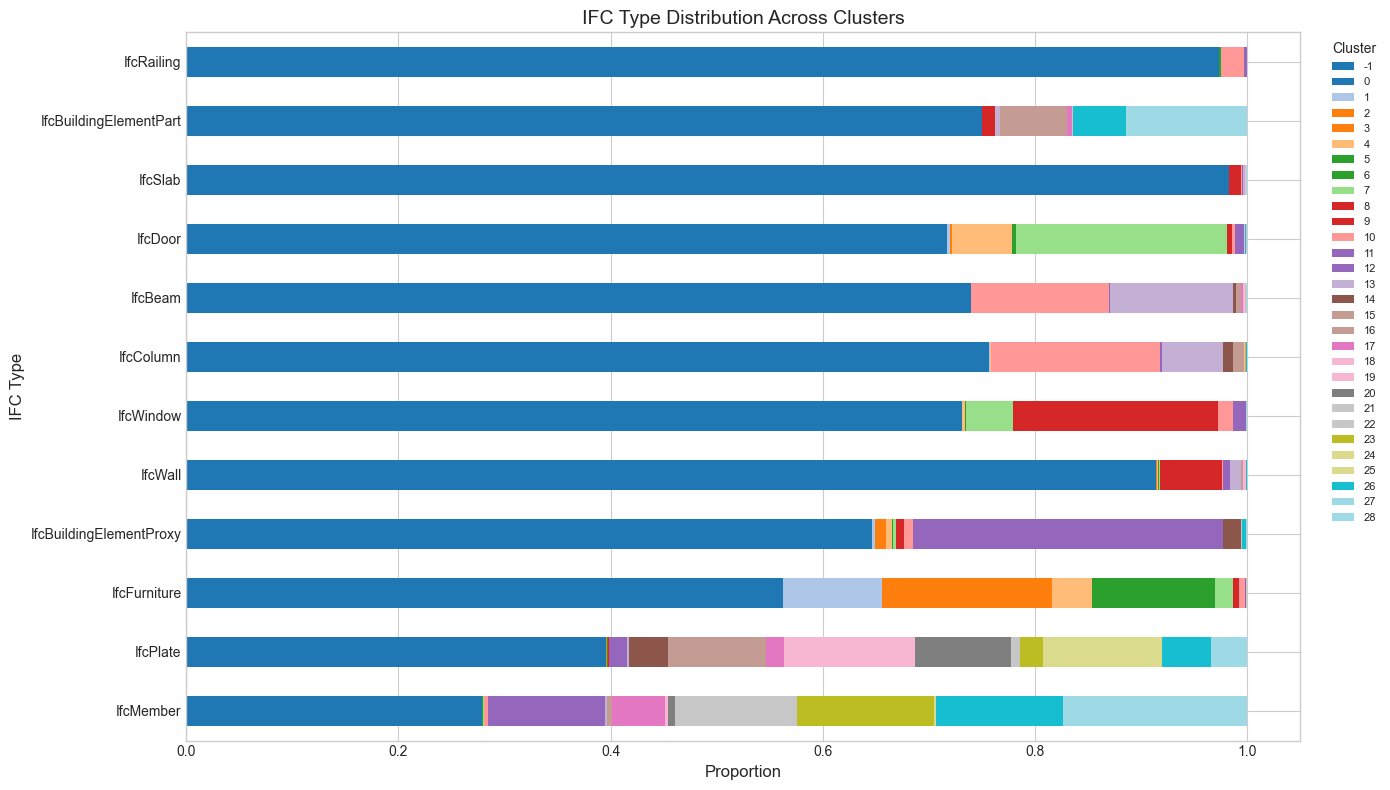

In [27]:
# How each IFC type is distributed across HDBSCAN clusters
plot_type_cluster_distribution(
    results['HDBSCAN']['result'].labels,
    df['IfcType'].values,
    top_n_types=12
)
plt.show()

### Interpretation Guide

**Purity Score:**
- `> 0.7`: Clusters align well with IFC types (good domain relevance)
- `0.4-0.7`: Moderate alignment
- `< 0.4`: Clustering doesn't respect IFC type boundaries

**What to look for in heatmaps:**
- Diagonal pattern = clusters correspond to IFC types
- Mixed rows = clusters capture cross-type geometric similarity
- One IFC type spanning many clusters = that type has geometric subtypes

## 10. Elbow Method Analysis

Re-evaluate KMeans algorithms using the elbow method (inertia curve) instead of silhouette score to see if it suggests a different k.

In [28]:
from sklearn.cluster import MiniBatchKMeans, BisectingKMeans
from tqdm.auto import tqdm

def compute_elbow_curve(X, k_range, algorithm='kmeans'):
    """Compute inertia for elbow method."""
    inertias = []
    for k in tqdm(k_range, desc=f'{algorithm} elbow'):
        if algorithm == 'kmeans':
            model = MiniBatchKMeans(n_clusters=k, batch_size=3072, n_init='auto', random_state=42)
        else:
            model = BisectingKMeans(n_clusters=k, random_state=42)
        model.fit(X)
        inertias.append(model.inertia_)
    return inertias

# Test wider range of k
k_range = list(range(2, 35))

# Compute elbow curves
print("Computing elbow curves...")
kmeans_inertias = compute_elbow_curve(X, k_range, 'kmeans')
bisecting_inertias = compute_elbow_curve(X, k_range, 'bisecting')

Computing elbow curves...


kmeans elbow:   0%|          | 0/33 [00:00<?, ?it/s]

bisecting elbow:   0%|          | 0/33 [00:00<?, ?it/s]

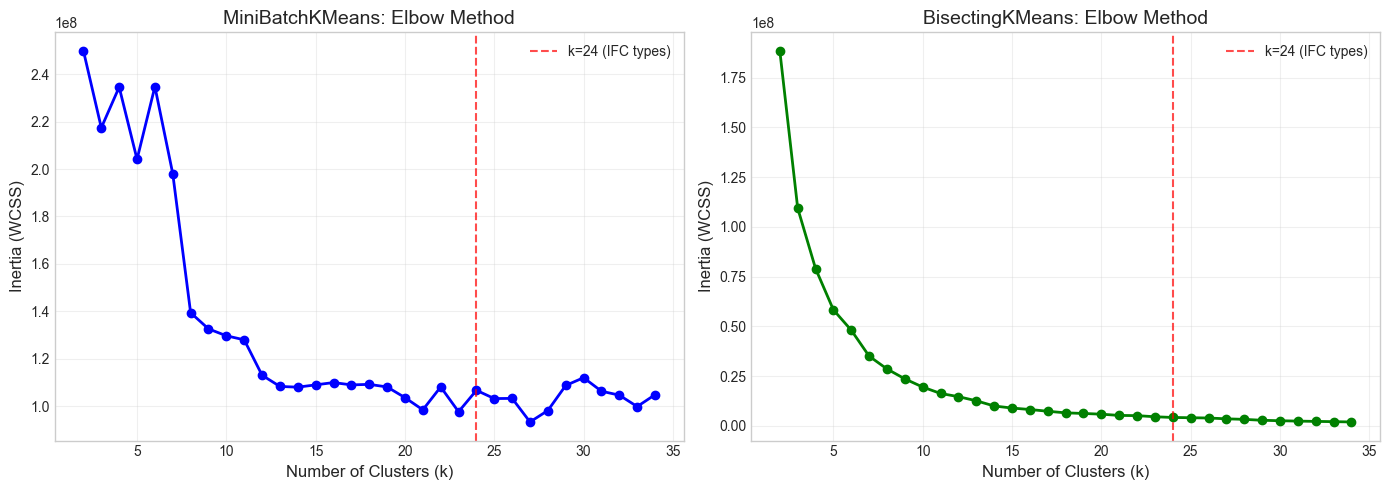


Inertia reduction rate (higher = steeper decline):
--------------------------------------------------
k= 3: KMeans  13.0%, Bisecting  41.9%
k= 4: KMeans  -7.9%, Bisecting  27.7%
k= 5: KMeans  13.0%, Bisecting  26.2%
k= 6: KMeans -15.0%, Bisecting  17.6%
k= 7: KMeans  15.7%, Bisecting  27.1%
k= 8: KMeans  29.6%, Bisecting  18.4%
k= 9: KMeans   4.9%, Bisecting  17.4%
k=10: KMeans   2.2%, Bisecting  17.4%
k=11: KMeans   1.3%, Bisecting  16.4%
k=12: KMeans  11.7%, Bisecting   9.8%
k=13: KMeans   4.2%, Bisecting  14.1%
k=14: KMeans   0.3%, Bisecting  20.7%
k=15: KMeans  -0.9%, Bisecting  10.3%
k=24: KMeans  -9.2%, Bisecting   7.8%


In [29]:
# Plot elbow curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KMeans
axes[0].plot(k_range, kmeans_inertias, 'bo-', linewidth=2, markersize=6)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title('MiniBatchKMeans: Elbow Method', fontsize=14)
axes[0].axvline(x=24, color='red', linestyle='--', alpha=0.7, label='k=24 (IFC types)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# BisectingKMeans
axes[1].plot(k_range, bisecting_inertias, 'go-', linewidth=2, markersize=6)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[1].set_title('BisectingKMeans: Elbow Method', fontsize=14)
axes[1].axvline(x=24, color='red', linestyle='--', alpha=0.7, label='k=24 (IFC types)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print inertia reduction rates to help identify elbow
print("\nInertia reduction rate (higher = steeper decline):")
print("-" * 50)
for i, k in enumerate(k_range[1:], 1):
    km_rate = (kmeans_inertias[i-1] - kmeans_inertias[i]) / kmeans_inertias[i-1] * 100
    bs_rate = (bisecting_inertias[i-1] - bisecting_inertias[i]) / bisecting_inertias[i-1] * 100
    if k <= 15 or k == 24:
        print(f"k={k:2d}: KMeans {km_rate:5.1f}%, Bisecting {bs_rate:5.1f}%")

### Re-run with Elbow-Suggested k

Based on the elbow curves, select k values and re-evaluate with IFC type analysis.

In [30]:
# Re-run with different k values for comparison
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

def fast_silhouette(X, labels, sample_size=10000):
    """Compute silhouette on a sample for speed (O(n^2) is slow for 128K)."""
    if len(X) > sample_size:
        np.random.seed(42)
        idx = np.random.choice(len(X), sample_size, replace=False)
        return silhouette_score(X[idx], labels[idx])
    return silhouette_score(X, labels)

# Professor-recommended k values
test_k_values = [7, 12, 18, 24, 30]

elbow_results = {}

for k in test_k_values:
    print(f"\n{'='*60}")
    print(f"Testing k={k}")
    print('='*60)
    
    # MiniBatchKMeans
    km = MiniBatchKMeans(n_clusters=k, batch_size=3072, n_init='auto', random_state=42)
    km_labels = km.fit_predict(X)
    km_sil = fast_silhouette(X, km_labels)
    km_ch = calinski_harabasz_score(X, km_labels)
    km_db = davies_bouldin_score(X, km_labels)
    
    # BisectingKMeans
    bk = BisectingKMeans(n_clusters=k,bisecting_strategy="largest_cluster", random_state=42)
    bk_labels = bk.fit_predict(X)
    bk_sil = fast_silhouette(X, bk_labels)
    bk_ch = calinski_harabasz_score(X, bk_labels)
    bk_db = davies_bouldin_score(X, bk_labels)
    
    # Store results
    elbow_results[f'KMeans_k{k}'] = {
        'labels': km_labels, 
        'silhouette': km_sil,
        'calinski_harabasz': km_ch,
        'davies_bouldin': km_db
    }
    elbow_results[f'Bisecting_k{k}'] = {
        'labels': bk_labels, 
        'silhouette': bk_sil,
        'calinski_harabasz': bk_ch,
        'davies_bouldin': bk_db
    }
    
    print(f"  KMeans:    sil={km_sil:.3f}, CH={km_ch:.0f}, DB={km_db:.3f}")
    print(f"  Bisecting: sil={bk_sil:.3f}, CH={bk_ch:.0f}, DB={bk_db:.3f}")
    
    # Check cluster balance for BisectingKMeans
    bk_sizes = pd.Series(bk_labels).value_counts()
    max_pct = bk_sizes.iloc[0] / len(bk_labels) * 100
    print(f"  Bisecting max cluster: {max_pct:.1f}% (balanced if < 50%)")


Testing k=7
  KMeans:    sil=0.435, CH=11204, DB=1.020
  Bisecting: sil=0.745, CH=20697, DB=0.858
  Bisecting max cluster: 85.0% (balanced if < 50%)

Testing k=12
  KMeans:    sil=0.295, CH=18107, DB=0.881
  Bisecting: sil=0.232, CH=11349, DB=1.025
  Bisecting max cluster: 21.7% (balanced if < 50%)

Testing k=18
  KMeans:    sil=0.266, CH=12553, DB=0.895
  Bisecting: sil=0.190, CH=7345, DB=1.010
  Bisecting max cluster: 9.4% (balanced if < 50%)

Testing k=24
  KMeans:    sil=0.294, CH=9544, DB=0.891
  Bisecting: sil=0.252, CH=5436, DB=1.013
  Bisecting max cluster: 7.3% (balanced if < 50%)

Testing k=30
  KMeans:    sil=0.294, CH=7280, DB=0.988
  Bisecting: sil=0.259, CH=4344, DB=1.022
  Bisecting max cluster: 6.1% (balanced if < 50%)


In [31]:
# Full metrics comparison table
print("Full Metrics Comparison:")
print("-" * 85)
print(f"{'Config':<18} {'Silhouette':>10} {'CH Index':>12} {'DB Index':>10} {'Purity':>10}")
print("-" * 85)

ifc_types = df['IfcType'].values

for name, res in elbow_results.items():
    analysis = analyze_cluster_composition(res['labels'], ifc_types)
    purity = analysis['purity']
    sil = res['silhouette']
    ch = res['calinski_harabasz']
    db = res['davies_bouldin']
    print(f"{name:<18} {sil:>10.3f} {ch:>12.0f} {db:>10.3f} {purity:>10.3f}")

print("-" * 85)
print("\nMetric interpretation:")
print("  Silhouette: [-1, 1] higher = better geometric separation")
print("  Calinski-Harabasz: [0, inf) higher = better defined clusters") 
print("  Davies-Bouldin: [0, inf) lower = better separation")
print("  Purity: [0, 1] higher = better semantic alignment with IFC types")

Full Metrics Comparison:
-------------------------------------------------------------------------------------
Config             Silhouette     CH Index   DB Index     Purity
-------------------------------------------------------------------------------------
KMeans_k7               0.435        11204      1.020      0.350
Bisecting_k7            0.745        20697      0.858      0.260
KMeans_k12              0.295        18107      0.881      0.388
Bisecting_k12           0.232        11349      1.025      0.375
KMeans_k18              0.266        12553      0.895      0.430
Bisecting_k18           0.190         7345      1.010      0.423
KMeans_k24              0.294         9544      0.891      0.453
Bisecting_k24           0.252         5436      1.013      0.437
KMeans_k30              0.294         7280      0.988      0.455
Bisecting_k30           0.259         4344      1.022      0.487
-------------------------------------------------------------------------------------

M

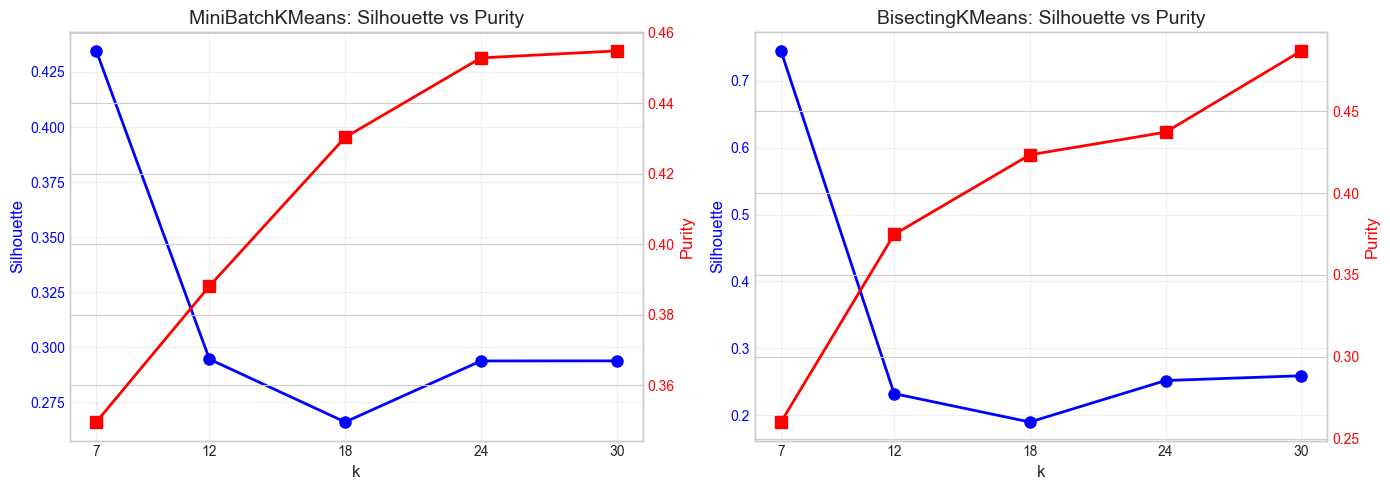

In [32]:
# Visualize silhouette vs purity tradeoff
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prepare data
km_data = [(k, elbow_results[f'KMeans_k{k}']['silhouette'], 
            analyze_cluster_composition(elbow_results[f'KMeans_k{k}']['labels'], ifc_types)['purity'])
           for k in test_k_values]
bk_data = [(k, elbow_results[f'Bisecting_k{k}']['silhouette'],
            analyze_cluster_composition(elbow_results[f'Bisecting_k{k}']['labels'], ifc_types)['purity'])
           for k in test_k_values]

# Plot KMeans
ks, sils, purs = zip(*km_data)
ax1 = axes[0]
ax1.plot(ks, sils, 'bo-', label='Silhouette', linewidth=2, markersize=8)
ax1.set_xlabel('k', fontsize=12)
ax1.set_ylabel('Silhouette', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')

ax1_twin = ax1.twinx()
ax1_twin.plot(ks, purs, 'rs-', label='Purity', linewidth=2, markersize=8)
ax1_twin.set_ylabel('Purity', color='red', fontsize=12)
ax1_twin.tick_params(axis='y', labelcolor='red')
ax1.set_title('MiniBatchKMeans: Silhouette vs Purity', fontsize=14)
ax1.set_xticks(ks)
ax1.grid(True, alpha=0.3)

# Plot BisectingKMeans
ks, sils, purs = zip(*bk_data)
ax2 = axes[1]
ax2.plot(ks, sils, 'bo-', label='Silhouette', linewidth=2, markersize=8)
ax2.set_xlabel('k', fontsize=12)
ax2.set_ylabel('Silhouette', color='blue', fontsize=12)
ax2.tick_params(axis='y', labelcolor='blue')

ax2_twin = ax2.twinx()
ax2_twin.plot(ks, purs, 'rs-', label='Purity', linewidth=2, markersize=8)
ax2_twin.set_ylabel('Purity', color='red', fontsize=12)
ax2_twin.tick_params(axis='y', labelcolor='red')
ax2.set_title('BisectingKMeans: Silhouette vs Purity', fontsize=14)
ax2.set_xticks(ks)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Detailed Analysis: k=24 (Matching IFC Type Count)

Since we have 24 IFC types, k=24 is a natural baseline to see if clusters can recover semantic categories.

In [33]:
# Detailed analysis for k=24 KMeans
print("KMeans k=7: Cluster Summary")
print("="*60)
print_cluster_summary(elbow_results['Bisecting_k18']['labels'], ifc_types, top_n=30)

KMeans k=7: Cluster Summary
Purity Score: 0.423

Top 30 Clusters by Dominant Type:
------------------------------------------------------------
Cluster  13: IfcWall                        (36.2%) - 12,143 samples
Cluster  12: IfcColumn                      (31.9%) - 11,988 samples
Cluster  11: IfcWindow                      (44.6%) - 11,697 samples
Cluster   6: IfcMember                      (47.5%) - 10,581 samples
Cluster   2: IfcFurniture                   (34.1%) - 10,455 samples
Cluster   9: IfcPlate                       (27.5%) - 9,451 samples
Cluster  14: IfcFurniture                   (53.4%) - 9,187 samples
Cluster   8: IfcMember                      (46.7%) - 8,760 samples
Cluster   7: IfcMember                      (51.0%) - 8,680 samples
Cluster   3: IfcPlate                       (47.1%) - 7,968 samples
Cluster   5: IfcBuildingElementProxy        (51.2%) - 6,127 samples
Cluster  10: IfcPlate                       (28.6%) - 6,031 samples
Cluster   4: IfcPlate              

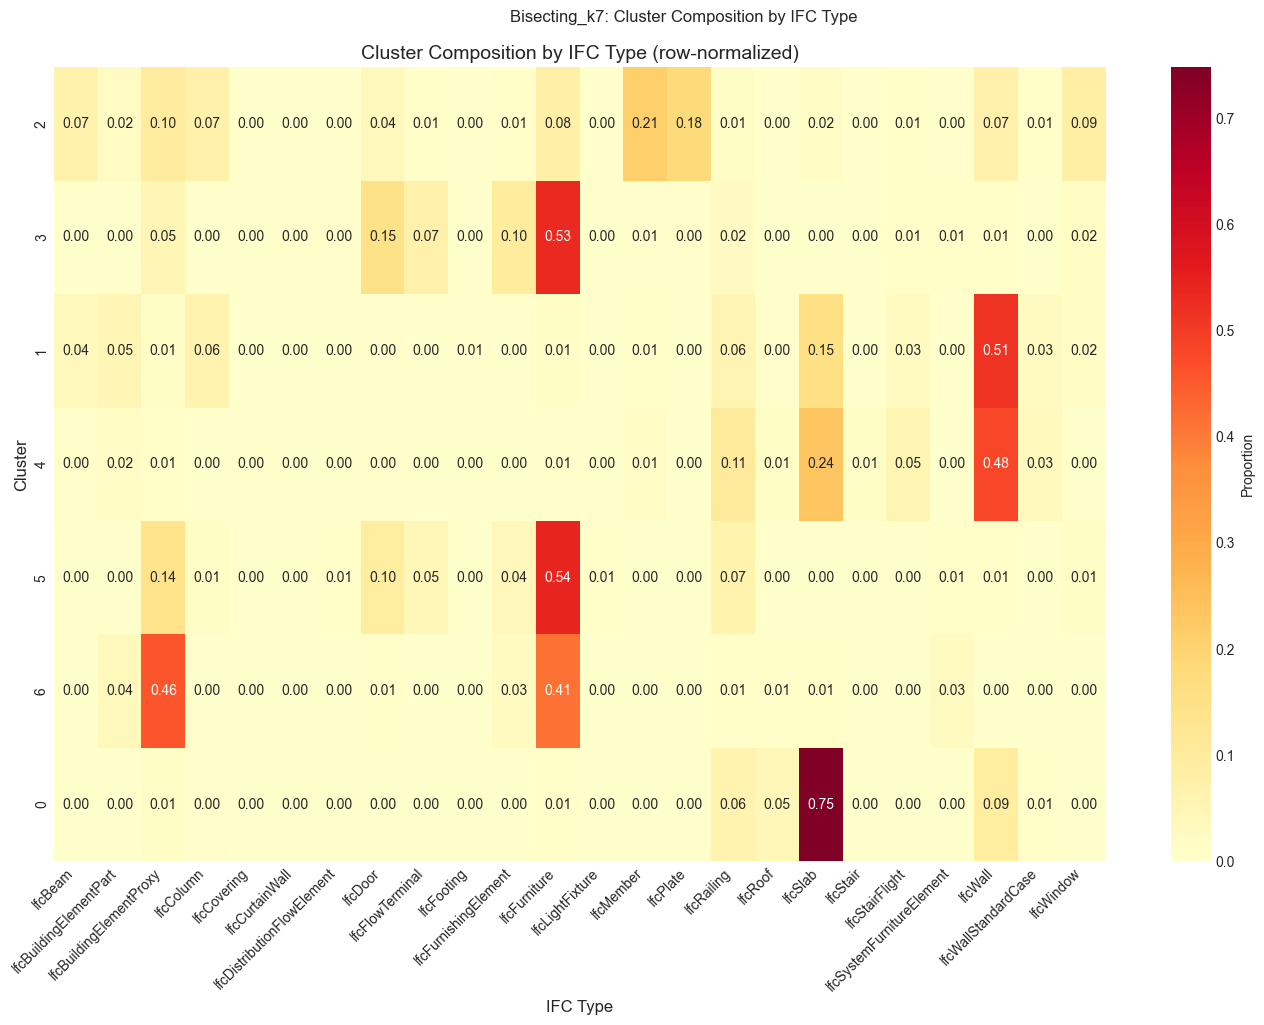

In [44]:
# Heatmap for k=24 KMeans
algo = 'Bisecting_k7'
plot_cluster_ifc_heatmap(
    elbow_results[algo]['labels'],
    ifc_types,
    top_n_clusters=24,
    top_n_types=24,
    normalize='index'
)
plt.suptitle(f'{algo}: Cluster Composition by IFC Type', y=1.02)
plt.show()

### Elbow Method Findings

**Key Observations:**
1. Elbow method typically suggests k in the 8-15 range (diminishing returns)
2. Silhouette decreases as k increases (expected - more clusters = more overlap)
3. Purity increases with k (more clusters = more specific groupings)

**Trade-off:**
- Low k: Better silhouette, worse purity (coarse grouping)
- High k: Worse silhouette, better purity (finer grouping)

**Conclusion:**
Neither elbow method nor silhouette optimization naturally recovers IFC semantic types, confirming that OBB features alone cannot discriminate BIM element categories.